# After the data extraction is done, then please find out the following:
1. A list of the top-10 videos based on the total views
2. A list of the bottom-10 videos based on the total views
3. The most liked video
4. The least liked video
5. The video with the highest duration
6. Apply sentiment analysis on the downloaded comments for each of the videos. For sentiment 
analysis, you can use VADER or any other tool of your choice. Your program should list the 
sentiments score for each of the movies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import seaborn as sns
import re

In [2]:
video_details_df = pd.read_csv('details_data.csv')
video_details_df.head()

,Unnamed: 0,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Favorite_Count,Comment_Count,Duration,Definition
0,0,K26_sDKnvMU,Toy Story (1995),Trailer for Toy Story (1995) captured from the...,102790,99,12,0,13,PT1M31S,sd
1,1,rEnOoWs3FuA,Grumpier Old Men (1995),"The more things change, the more they stay the...",164820,218,8,0,12,PT1M51S,sd
2,2,2GfZl4kuVNI,Heat (1995),"Director: Michael Mann.\nCast: Al Pacino, Robe...",1083869,5445,162,0,524,PT2M28S,hd
3,3,-C-xXZyX2zU,Tom and Huck (1995),A preview for this 90s disney movie. From the ...,168310,176,17,0,83,PT1M,sd
4,4,lcOqUE0u1LM,GoldenEye (1995),"Release Date: November 13, 1995\n\nPierce Bros...",208230,968,33,0,100,PT2M52S,hd


In [3]:
video_details_df.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition
0,K26_sDKnvMU,Toy Story (1995),Trailer for Toy Story (1995) captured from the...,102790,99,12,13,PT1M31S,sd
1,rEnOoWs3FuA,Grumpier Old Men (1995),"The more things change, the more they stay the...",164820,218,8,12,PT1M51S,sd
2,2GfZl4kuVNI,Heat (1995),"Director: Michael Mann.\nCast: Al Pacino, Robe...",1083869,5445,162,524,PT2M28S,hd
3,-C-xXZyX2zU,Tom and Huck (1995),A preview for this 90s disney movie. From the ...,168310,176,17,83,PT1M,sd
4,lcOqUE0u1LM,GoldenEye (1995),"Release Date: November 13, 1995\n\nPierce Bros...",208230,968,33,100,PT2M52S,hd
...,...,...,...,...,...,...,...,...,...
2898,SmHnaWoP02U,Biloxi Blues (1988),Subscribe to TRAILERS: http://bit.ly/sxaw6h\nS...,63822,145,9,11,PT1M28S,sd
2899,9L2sog6VEdw,Cocktail (1988),¿Eres coleccionista? ¿Compras DVD y VHS? Pásat...,284105,451,36,29,PT2M12S,sd
2900,fqfJqLFQSIk,Coming to America (1988),A pampered African prince (Eddie Murphy) wants...,949551,2431,137,181,PT2M34S,sd
2901,zkhbVjiPTv0,"Dead Pool, The (1988)",30 second spot for Clint Eastwood film The Dea...,22627,35,0,3,PT31S,sd


# 1. A list of the top-10 videos based on the total views

In [4]:
# Statistical View
df_highest_views = video_details_df.nlargest(10, 'View_Count')
df_highest_views['Title'] = df_highest_views['Title'].str[:40]
df_highest_views['View_Count_Millions'] = df_highest_views['View_Count'] / 1000000
df_highest_views.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition,View_Count_Millions
1189,gv2AOQiGAwg,High Art (1998),"zwiastun filmu „High Art""\r\nReż. Lisa Cholode...",19685025,6902,4774,200,PT1M28S,hd,19.685025
2407,4FHpmn-KYec,Romeo and Juliet (1968),NaN,14821302,75714,2194,4135,PT4M20S,sd,14.821302
1945,NJIjNs_s2NI,RoboCop 2 (1990),RoboCop 2 movie clips: http://j.mp/1AUQliM\nBU...,11400302,86376,2994,6716,PT2M13S,hd,11.400302
2578,lgo3Hb5vWLE,Requiem for a Dream (2000),Requiem for a Dream exposes four paralleled in...,8119309,11234,687,4200,PT1M34S,sd,8.119309
1153,FpfDTg4lbNE,Live Flesh (Carne trémula) (1997),we have a new channel for horror/sci-fi fans: ...,7424724,1232,948,67,PT1M35S,sd,7.424724
1924,SUXWAEX2jlg,Fight Club (1999),"Fight Club Trailer - HD\r\n\r\n\r\nfight club,...",6747310,18385,602,2713,PT2M3S,hd,6.747310
360,vHLgob-PpIk,"Nightmare Before Christmas, The (1993)","This is the introduction to Tim Burton's ""The ...",6746693,31114,2378,2744,PT4M29S,sd,6.746693
2345,tGAa8WF0vxo,"Idiots, The (Idioterne) (1998)",Not perfect subtitles,6653489,1114,1226,122,PT2M22S,sd,6.653489
186,s7EdQ4FqbhY,Pulp Fiction (1994),Pulp Fiction movie clips: http://j.mp/1L5eDtj\...,6368726,29786,792,1796,PT3M6S,hd,6.368726
1956,4OiMOHRDs14,Princess Mononoke (Mononoke-hime) (1997),A beautifully realised tale of civilisation ve...,5965254,40729,886,2128,PT1M43S,hd,5.965254


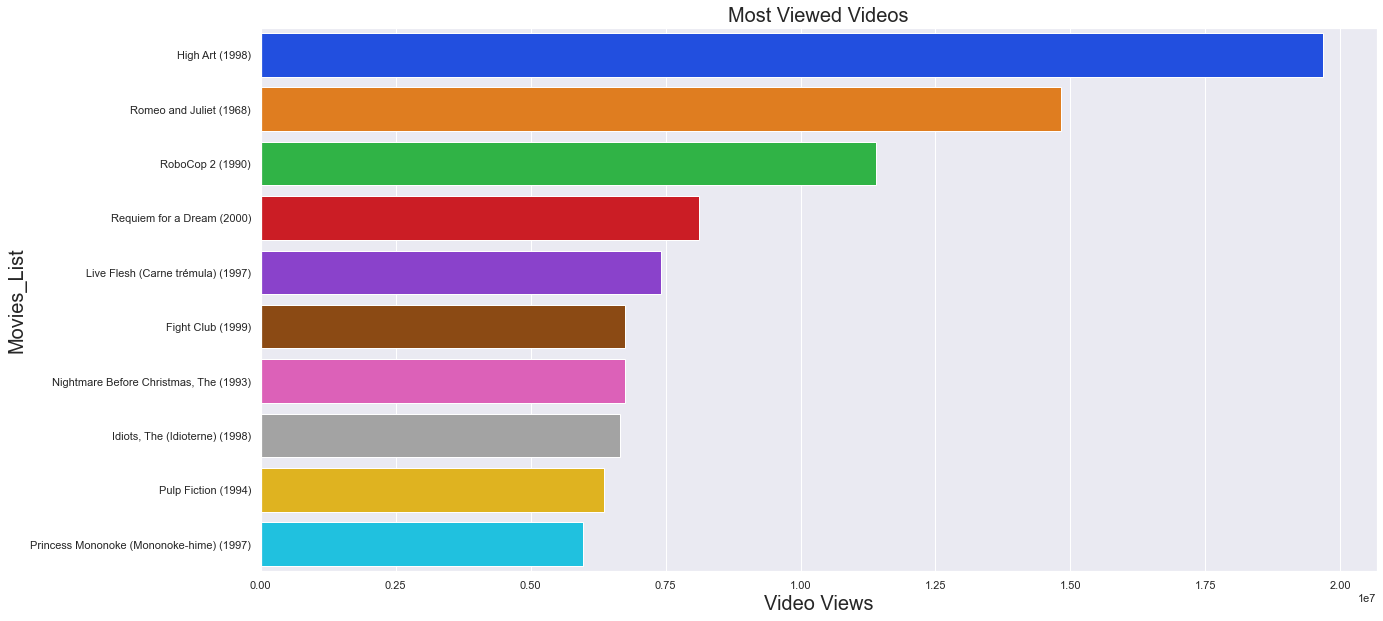

In [5]:
# Graphical view
sns.set(rc={'figure.figsize':(20,10),"axes.titlesize":20,"axes.labelsize":20})
plot = sns.barplot(x="View_Count", y="Title", data=df_highest_views, palette="bright")
plot.set(xlabel='Video Views', ylabel='Movies_List')
plot.set_title('Most Viewed Videos')
plt.show()

# 2. A list of the bottom-10 videos based on the total views

In [6]:
# Statistical View
df_lowest_views = video_details_df.nsmallest(10, 'View_Count')
df_lowest_views['Title'] = df_lowest_views['Title'].str[:40]
df_lowest_views.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition
1159,ZGjNEbDJk6M,Love Walked In (1998),"Mit ""The Big Band Convention"" hat sich in der ...",225,0,0,0,PT3M30S,sd
1133,dzYCTejXbx0,Eden (1997),Eden Let Your Spirits Soar Trailer 1998\nDirec...,258,1,0,0,PT1M52S,sd
1940,DaezhUFweTY,"Brother, Can You Spare a Dime? (1975)",Mr. Faulk Landrum talks to the Read Through th...,343,2,0,0,PT1H8M49S,sd
2319,_3o4gqFnAP4,Sacco and Vanzetti (Sacco e Vanzetti) (1,http://www.imdb.com/title/tt0067698/\n\nLegend...,399,1,0,0,PT1M11S,hd
705,1AfBwPrB4pM,"Leopard Son, The (1996)",The Leopard Son Trailer 1996\nDirector: Hugo V...,503,0,0,0,PT1M4S,sd
2087,WtxXTxKmNxs,Trans (1998),Trans was written and directed by Julian Goldb...,577,6,2,7,PT3M2S,hd
1833,Fn02k1dx1Ns,Rosie (1998),Rosie was directed by Patrice Toye. This movie...,660,5,0,2,PT3M8S,hd
467,7AG6yN9JP5g,Low Life (1994),SPITFIRE - RUBBER ROSIE - LOWLIFE RECORDINGS 1...,763,13,0,1,PT3M19S,hd
561,xWGteh1hSlk,"Philadelphia Story, The (1940)",Philadelphia heiress Tracy Lord throws out her...,813,1,0,0,PT3M32S,hd
604,avI86TPMJi4,Bringing Up Baby (1938),David Huxley is waiting to get a bone he needs...,824,1,0,0,PT2M20S,sd


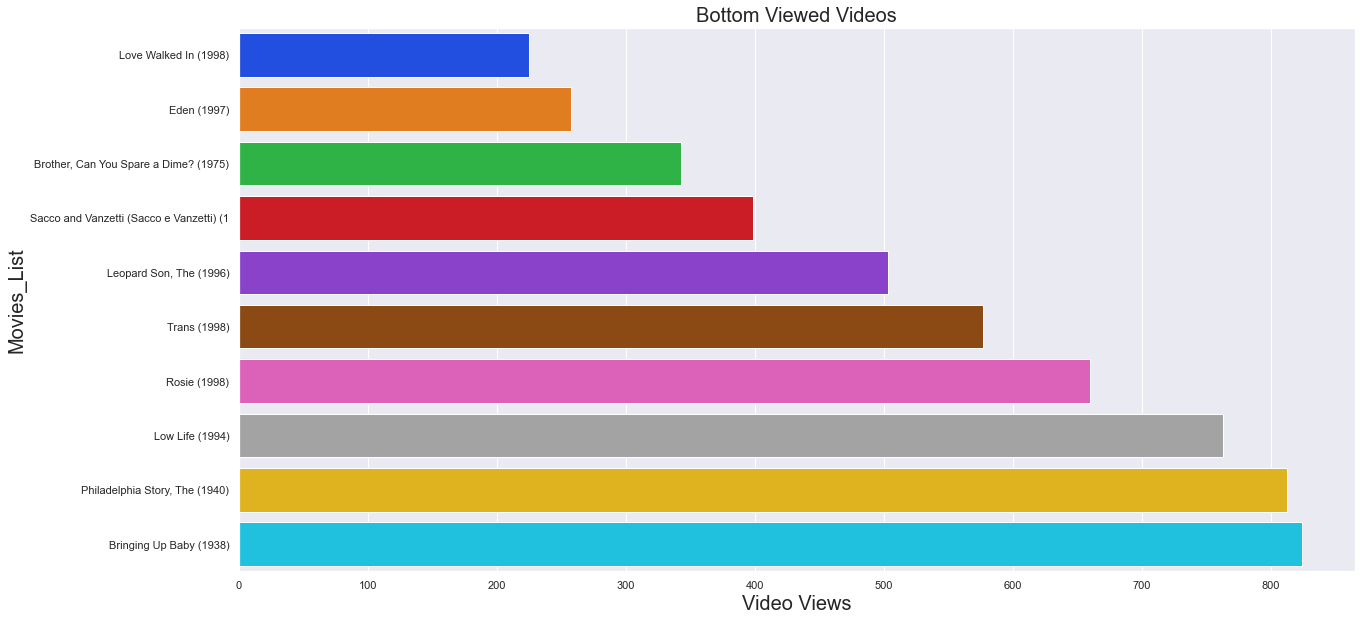

In [7]:
# Graphical view
plot = sns.barplot(x="View_Count", y="Title", data=df_lowest_views, palette="bright")
plot.set(xlabel='Video Views', ylabel='Movies_List')
plot.set_title('Bottom Viewed Videos')
plt.show()

# 3. The most liked video

In [8]:
# Statistical View
df_most_likes = video_details_df.nlargest(10, 'Like_Count')
df_most_likes['Title'] = df_most_likes['Title'].str[:40]
df_most_likes.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition
1945,NJIjNs_s2NI,RoboCop 2 (1990),RoboCop 2 movie clips: http://j.mp/1AUQliM\nBU...,11400302,86376,2994,6716,PT2M13S,hd
2407,4FHpmn-KYec,Romeo and Juliet (1968),NaN,14821302,75714,2194,4135,PT4M20S,sd
1956,4OiMOHRDs14,Princess Mononoke (Mononoke-hime) (1997),A beautifully realised tale of civilisation ve...,5965254,40729,886,2128,PT1M43S,hd
360,vHLgob-PpIk,"Nightmare Before Christmas, The (1993)","This is the introduction to Tim Burton's ""The ...",6746693,31114,2378,2744,PT4M29S,sd
186,s7EdQ4FqbhY,Pulp Fiction (1994),Pulp Fiction movie clips: http://j.mp/1L5eDtj\...,6368726,29786,792,1796,PT3M6S,hd
2331,BEq-wydAhdI,Third World Cop (1999),Third World Cop is a 1999 Jamaican action-crim...,3658957,29559,3290,2621,PT1H38M28S,hd
1703,bD7bpG-zDJQ,Star Wars: Episode I - The Phantom Menac,Subscribe: http://bit.ly/SubscribeToStarWars\n...,4962741,26427,1328,3497,PT2M13S,hd
545,sY1S34973zA,"Godfather, The (1972)",Update 7/14/16\nThanks for all the views! the ...,5241762,23322,752,1454,PT1M35S,hd
111,U9a5tZSKDOU,Kids (1995),Subscribe to TRAILERS: http://bit.ly/sxaw6h\nS...,4565769,18657,738,2051,PT1M47S,hd
500,8LuxOYIpu-I,Trainspotting (1996),Subscribe to CLASSIC TRAILERS: http://bit.ly/1...,3836040,18441,468,595,PT1M55S,hd


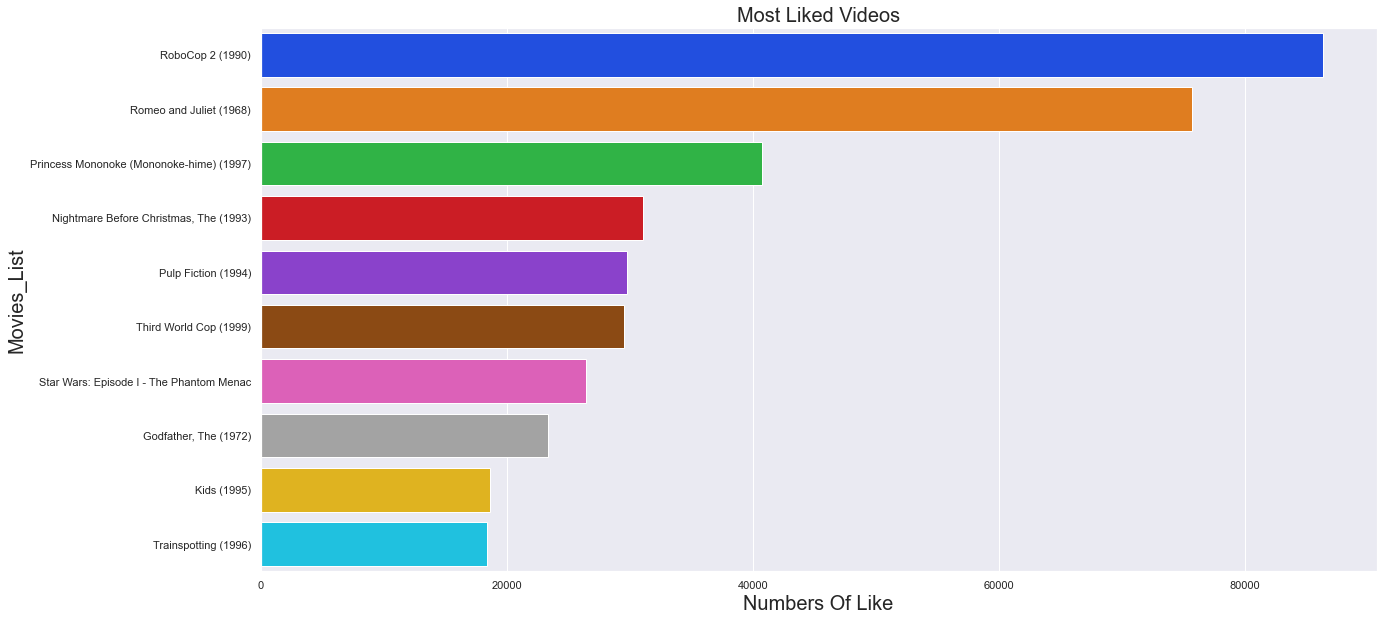

In [9]:
# Graphical view
plot = sns.barplot(x="Like_Count", y="Title", data=df_most_likes, palette="bright")
plot.set(xlabel='Numbers Of Like', ylabel='Movies_List')
plot.set_title('Most Liked Videos')
plt.show()

# 4. The least liked video

In [10]:
# Statistical View
df_least_likes = video_details_df.nsmallest(10, 'Like_Count')
df_least_likes['Title'] = df_least_likes['Title'].str[:40]
df_least_likes.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition
401,q4pIsTM3UZM,Bread and Chocolate (Pane e cioccolata),Bread & Chocolate 3,1457,0,0,0,PT9M32S,sd
705,1AfBwPrB4pM,"Leopard Son, The (1996)",The Leopard Son Trailer 1996\nDirector: Hugo V...,503,0,0,0,PT1M4S,sd
1159,ZGjNEbDJk6M,Love Walked In (1998),"Mit ""The Big Band Convention"" hat sich in der ...",225,0,0,0,PT3M30S,sd
530,tS8_LX7Z5CI,Regular Guys (Echte Kerle) (1996),Diese unbändige Kraft ist wirklich beeindrucke...,3798,1,2,1,PT1M25S,sd
561,xWGteh1hSlk,"Philadelphia Story, The (1940)",Philadelphia heiress Tracy Lord throws out her...,813,1,0,0,PT3M32S,hd
604,avI86TPMJi4,Bringing Up Baby (1938),David Huxley is waiting to get a bone he needs...,824,1,0,0,PT2M20S,sd
847,_zHobY-FC0Q,Breathing Room (1996),"Naakt in een verlaten kamer, met 13 vreemden, ...",3017,1,0,2,PT2M5S,sd
1133,dzYCTejXbx0,Eden (1997),Eden Let Your Spirits Soar Trailer 1998\nDirec...,258,1,0,0,PT1M52S,sd
1406,HGfQ87J6xQk,Mr. & Mrs. Smith (1941),,2252,1,0,0,PT45S,sd
2319,_3o4gqFnAP4,Sacco and Vanzetti (Sacco e Vanzetti) (1,http://www.imdb.com/title/tt0067698/\n\nLegend...,399,1,0,0,PT1M11S,hd


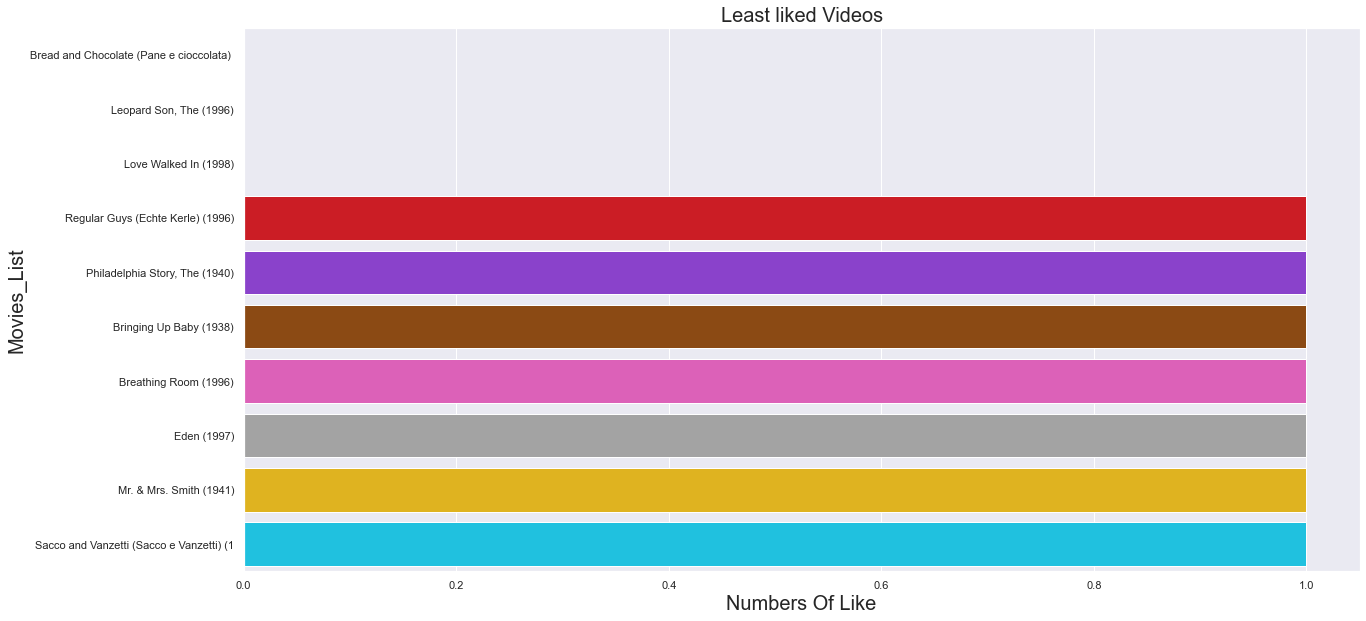

In [11]:
# Graphical view
plot = sns.barplot(x="Like_Count", y="Title", data=df_least_likes, palette="bright")
plot.set(xlabel='Numbers Of Like', ylabel='Movies_List')
plot.set_title('Least liked Videos')
plt.show()

# 5. The video with the highest duration

In [12]:
def time_conversion(s):
    ls = ["00","00","00"]
    
    if "H" in s:
        n = re.split("H", s)
        ls[0] = n[0]
        s = n[1]

    if "M" in s:
        n = re.split("M", s)
        ls[1] = n[0]
        s = n[1]

    if "S" in s:
        n = re.split("S", s)
        ls[2] = n[0]
    
    sep = ":"
    duration = sep.join(ls)

    return duration

def replace_PT(r):
    r = r.replace('PT','')
    return r

In [13]:
video_details_df['Duration'] = video_details_df['Duration'].apply(lambda x: x.replace(x,replace_PT(x)))
video_details_df

,Unnamed: 0,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Favorite_Count,Comment_Count,Duration,Definition
0,0,K26_sDKnvMU,Toy Story (1995),Trailer for Toy Story (1995) captured from the...,102790,99,12,0,13,1M31S,sd
1,1,rEnOoWs3FuA,Grumpier Old Men (1995),"The more things change, the more they stay the...",164820,218,8,0,12,1M51S,sd
2,2,2GfZl4kuVNI,Heat (1995),"Director: Michael Mann.\nCast: Al Pacino, Robe...",1083869,5445,162,0,524,2M28S,hd
3,3,-C-xXZyX2zU,Tom and Huck (1995),A preview for this 90s disney movie. From the ...,168310,176,17,0,83,1M,sd
4,4,lcOqUE0u1LM,GoldenEye (1995),"Release Date: November 13, 1995\n\nPierce Bros...",208230,968,33,0,100,2M52S,hd
...,...,...,...,...,...,...,...,...,...,...,...
2898,2898,SmHnaWoP02U,Biloxi Blues (1988),Subscribe to TRAILERS: http://bit.ly/sxaw6h\nS...,63822,145,9,0,11,1M28S,sd
2899,2899,9L2sog6VEdw,Cocktail (1988),¿Eres coleccionista? ¿Compras DVD y VHS? Pásat...,284105,451,36,0,29,2M12S,sd
2900,2900,fqfJqLFQSIk,Coming to America (1988),A pampered African prince (Eddie Murphy) wants...,949551,2431,137,0,181,2M34S,sd
2901,2901,zkhbVjiPTv0,"Dead Pool, The (1988)",30 second spot for Clint Eastwood film The Dea...,22627,35,0,0,3,31S,sd


In [14]:
video_details_df['Duration'] = video_details_df['Duration'].apply(lambda x: x.replace(x,time_conversion(x)))
video_details_df.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition
0,K26_sDKnvMU,Toy Story (1995),Trailer for Toy Story (1995) captured from the...,102790,99,12,13,00:1:31,sd
1,rEnOoWs3FuA,Grumpier Old Men (1995),"The more things change, the more they stay the...",164820,218,8,12,00:1:51,sd
2,2GfZl4kuVNI,Heat (1995),"Director: Michael Mann.\nCast: Al Pacino, Robe...",1083869,5445,162,524,00:2:28,hd
3,-C-xXZyX2zU,Tom and Huck (1995),A preview for this 90s disney movie. From the ...,168310,176,17,83,00:1:00,sd
4,lcOqUE0u1LM,GoldenEye (1995),"Release Date: November 13, 1995\n\nPierce Bros...",208230,968,33,100,00:2:52,hd
...,...,...,...,...,...,...,...,...,...
2898,SmHnaWoP02U,Biloxi Blues (1988),Subscribe to TRAILERS: http://bit.ly/sxaw6h\nS...,63822,145,9,11,00:1:28,sd
2899,9L2sog6VEdw,Cocktail (1988),¿Eres coleccionista? ¿Compras DVD y VHS? Pásat...,284105,451,36,29,00:2:12,sd
2900,fqfJqLFQSIk,Coming to America (1988),A pampered African prince (Eddie Murphy) wants...,949551,2431,137,181,00:2:34,sd
2901,zkhbVjiPTv0,"Dead Pool, The (1988)",30 second spot for Clint Eastwood film The Dea...,22627,35,0,3,00:00:31,sd


In [15]:
def duration_into_seconds(time):  
    parts = time.split(':')
    return sum(x * int(t) for x, t in zip([3600, 60, 1], parts))

In [16]:
video_details_df['Duration_In_Sec'] = video_details_df['Duration'].apply(lambda x:duration_into_seconds(x))
video_details_df.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition,Duration_In_Sec
0,K26_sDKnvMU,Toy Story (1995),Trailer for Toy Story (1995) captured from the...,102790,99,12,13,00:1:31,sd,91
1,rEnOoWs3FuA,Grumpier Old Men (1995),"The more things change, the more they stay the...",164820,218,8,12,00:1:51,sd,111
2,2GfZl4kuVNI,Heat (1995),"Director: Michael Mann.\nCast: Al Pacino, Robe...",1083869,5445,162,524,00:2:28,hd,148
3,-C-xXZyX2zU,Tom and Huck (1995),A preview for this 90s disney movie. From the ...,168310,176,17,83,00:1:00,sd,60
4,lcOqUE0u1LM,GoldenEye (1995),"Release Date: November 13, 1995\n\nPierce Bros...",208230,968,33,100,00:2:52,hd,172
...,...,...,...,...,...,...,...,...,...,...
2898,SmHnaWoP02U,Biloxi Blues (1988),Subscribe to TRAILERS: http://bit.ly/sxaw6h\nS...,63822,145,9,11,00:1:28,sd,88
2899,9L2sog6VEdw,Cocktail (1988),¿Eres coleccionista? ¿Compras DVD y VHS? Pásat...,284105,451,36,29,00:2:12,sd,132
2900,fqfJqLFQSIk,Coming to America (1988),A pampered African prince (Eddie Murphy) wants...,949551,2431,137,181,00:2:34,sd,154
2901,zkhbVjiPTv0,"Dead Pool, The (1988)",30 second spot for Clint Eastwood film The Dea...,22627,35,0,3,00:00:31,sd,31


In [17]:
# Statistical View
df_highest_duration = video_details_df.nlargest(1, 'Duration_In_Sec')
df_highest_duration['Title'] = df_highest_duration['Title'].str[:40]
df_highest_duration.drop(['Unnamed: 0', 'Favorite_Count'], axis=1)

,VideoID,Title,Description,View_Count,Like_Count,Dislike_Count,Comment_Count,Duration,Definition,Duration_In_Sec
1415,uwkfM-Gi7KU,Blackmail (1929),Two early films from the Master of Suspense po...,76267,332,29,1,2:44:46,sd,9886


# 6. Apply sentiment analysis on the downloaded comments for each of the videos. For sentiment analysis, you can use VADER or any other tool of your choice. Your program should list the sentiments score for each of the movies

In [18]:
comments_df = pd.read_csv("comment_data.csv")
comments_df.head()

,Unnamed: 0,videoID,Title,Comments
0,0,K26_sDKnvMU,Toy Story (1995),"[""At first Toy Story wasn't confirmed as a Pix..."
1,1,rEnOoWs3FuA,Grumpier Old Men (1995),"['1:36 *GRUMPY⬅️ER* \n *GRUMPIER*', ""I..."
2,2,2GfZl4kuVNI,Heat (1995),"['""Told you I\'m never going back"" ..."
3,3,-C-xXZyX2zU,Tom and Huck (1995),['What a funny movie! Brad was awesome actor!!...
4,4,lcOqUE0u1LM,GoldenEye (1995),['Every Bond is has their place cemented in fi...


In [19]:
comments_df.drop(['Unnamed: 0'], axis=1)

,videoID,Title,Comments
0,K26_sDKnvMU,Toy Story (1995),"[""At first Toy Story wasn't confirmed as a Pix..."
1,rEnOoWs3FuA,Grumpier Old Men (1995),"['1:36 *GRUMPY⬅️ER* \n *GRUMPIER*', ""I..."
2,2GfZl4kuVNI,Heat (1995),"['""Told you I\'m never going back"" ..."
3,-C-xXZyX2zU,Tom and Huck (1995),['What a funny movie! Brad was awesome actor!!...
4,lcOqUE0u1LM,GoldenEye (1995),['Every Bond is has their place cemented in fi...
...,...,...,...
3056,iJC4R1uXDaE,They Live (1988),"['facebook smartglasses anyone?', 'The Biden a..."
3057,Mp5bHn8oQhk,Dead Bang (1989),"['Not to be confused with Jerry Beck, cartoon ..."
3058,yZs9Btf2ADw,"Shootist, The (1976)",['I just rewatched it for the first time in ye...
3059,ZHto8p6qIDg,Any Which Way You Can (1980),['Philo Beddoe toughest movie character of all...


In [20]:
positive_sentiments=[]
negative_sentiments=[]
neutral_sentiments=[]
label_sentiments=[]

def sentiment_scores(comment):
 
    sid_obj = SentimentIntensityAnalyzer()
 
    sentiment_dict = sid_obj.polarity_scores(comment)
     
    print("Overall sentiment dictionary is : ", sentiment_dict)
    print("Movie was rated as ",negative_sentiments.append(sentiment_dict['neg']*100), "% Negative")
    print("Movie was rated as ",neutral_sentiments.append(sentiment_dict['neu']*100), "% Neutral")
    print("Movie was rated as ",positive_sentiments.append(sentiment_dict['pos']*100), "% Positive")
 
    print("Sentence Overall Rated As", end = " ")
 
    if sentiment_dict['compound'] > 0 :
        label_sentiments.append("Positive")
 
    elif sentiment_dict['compound'] < 0:
        label_sentiments.append("Negative")
        
    elif sentiment_dict['compound'] == 0:
        label_sentiments.append("Neutral")

In [21]:
if __name__ == "__main__" :
 
    comments_df['Comments'].apply(lambda x: sentiment_scores(x))

Overall sentiment dictionary is :  {'neg': 0.033, 'neu': 0.914, 'pos': 0.053, 'compound': 0.2649}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 0.874, 'pos': 0.126, 'compound': 0.932}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.062, 'neu': 0.742, 'pos': 0.196, 'compound': 0.9999}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.081, 'neu': 0.75, 'pos': 0.169, 'compound': 0.9986}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.085, 'neu': 0.719, 'pos': 0.196, 'c

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.084, 'neu': 0.731, 'pos': 0.185, 'compound': 0.9998}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.096, 'neu': 0.904, 'pos': 0.0, 'compound': -0.5425}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.08, 'neu': 0.92, 'pos': 0.0, 'compound': -0.25}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 0.628, 'pos': 0.372, 'compound': 0.9899}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 0.7

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.069, 'neu': 0.744, 'pos': 0.187, 'compound': 0.9998}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.089, 'neu': 0.691, 'pos': 0.22, 'compound': 0.9997}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.062, 'neu': 0.757, 'pos': 0.18, 'compound': 0.9995}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.103, 'neu': 0.804, 'pos': 0.094, 'compound': -0.34}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.032, 'ne

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.154, 'neu': 0.562, 'pos': 0.284, 'compound': 0.9494}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.045, 'neu': 0.651, 'pos': 0.304, 'compound': 0.9999}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.123, 'neu': 0.681, 'pos': 0.196, 'compound': 0.9993}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.077, 'neu': 0.653, 'pos': 0.27, 'compound': 0.9973}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.091, '

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.14, 'neu': 0.622, 'pos': 0.238, 'compound': 0.9997}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.076, 'neu': 0.777, 'pos': 0.147, 'compound': 0.9996}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.059, 'neu': 0.659, 'pos': 0.282, 'compound': 0.9999}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.088, 'neu': 0.739, 'pos': 0.173, 'compound': 0.992}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.072, 'n

...

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.018, 'neu': 0.848, 'pos': 0.134, 'compound': 0.9685}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.132, 'neu': 0.764, 'pos': 0.104, 'compound': -0.8394}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.039, 'neu': 0.831, 'pos': 0.13, 'compound': 0.9071}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.036, 'neu': 0.678, 'pos': 0.286, 'compound': 0.9941}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'n

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.061, 'neu': 0.639, 'pos': 0.3, 'compound': 1.0}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.071, 'neu': 0.634, 'pos': 0.295, 'compound': 0.9999}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.054, 'neu': 0.796, 'pos': 0.15, 'compound': 0.7848}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.059, 'neu': 0.816, 'pos': 0.125, 'compound': 0.9312}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 1

Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.037, 'neu': 0.797, 'pos': 0.166, 'compound': 0.9958}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 0.866, 'pos': 0.134, 'compound': 0.7783}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.051, 'neu': 0.715, 'pos': 0.234, 'compound': 0.9999}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.153, 'neu': 0.66, 'pos': 0.187, 'compound': 0.9986}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.004, 'neu': 0.756, 'pos': 0.24, 'compound': 0.9985}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.063, 'neu': 0.68, 'pos': 0.256, 'compound': 0.9991}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.031, 'neu': 0.749, 'pos': 0.22, 'compound': 0.9987}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.084, 'neu': 0.529, 'pos': 0.387, 'compound': 0.9115}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.129, 'ne

Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.088, 'neu': 0.775, 'pos': 0.137, 'compound': 0.9773}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.168, 'neu': 0.832, 'pos': 0.0, 'compound': -0.431}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As Overall sentiment dictionary is :  {'neg': 0.087, 'neu': 0.703, 'pos': 0.21, 'compound': 0.9996}
Movie was rated as  None % Negative
Movie was rated as  None % Neutral
Movie was rated as  None % Positive
Sentence Overall Rated As 

In [22]:
comments_df['Positive_Score']=positive_sentiments
comments_df['Negative_Score']=negative_sentiments
comments_df['Neutral_Score']=neutral_sentiments
comments_df['Sentiments_Category']=label_sentiments

In [23]:
comments_df

,Unnamed: 0,videoID,Title,Comments,Positive_Score,Negative_Score,Neutral_Score,Sentiments_Category
0,0,K26_sDKnvMU,Toy Story (1995),"[""At first Toy Story wasn't confirmed as a Pix...",5.3,3.3,91.4,Positive
1,1,rEnOoWs3FuA,Grumpier Old Men (1995),"['1:36 *GRUMPY⬅️ER* \n *GRUMPIER*', ""I...",12.6,0.0,87.4,Positive
2,2,2GfZl4kuVNI,Heat (1995),"['""Told you I\'m never going back"" ...",19.6,6.2,74.2,Positive
3,3,-C-xXZyX2zU,Tom and Huck (1995),['What a funny movie! Brad was awesome actor!!...,16.9,8.1,75.0,Positive
4,4,lcOqUE0u1LM,GoldenEye (1995),['Every Bond is has their place cemented in fi...,19.6,8.5,71.9,Positive
...,...,...,...,...,...,...,...,...
3056,3056,iJC4R1uXDaE,They Live (1988),"['facebook smartglasses anyone?', 'The Biden a...",17.1,7.0,75.9,Positive
3057,3057,Mp5bHn8oQhk,Dead Bang (1989),"['Not to be confused with Jerry Beck, cartoon ...",24.5,0.0,75.5,Positive
3058,3058,yZs9Btf2ADw,"Shootist, The (1976)",['I just rewatched it for the first time in ye...,13.7,8.8,77.5,Positive
3059,3059,ZHto8p6qIDg,Any Which Way You Can (1980),['Philo Beddoe toughest movie character of all...,0.0,16.8,83.2,Negative


# 7. The top-10 videos that have the highest positive sentiment scores, which we have calculated from the comments

In [24]:
# Statistical View
df_positive_sent = comments_df.nlargest(10, 'Positive_Score')
df_positive_sent['Title'] = df_positive_sent['Title'].str[:40]
df_positive_sent.drop(['Unnamed: 0'], axis=1)

,videoID,Title,Comments,Positive_Score,Negative_Score,Neutral_Score,Sentiments_Category
300,hZPReKHCWDg,Dangerous Game (1993),['Masterpiece'],100.0,0.0,0.0,Positive
1431,LALkkZEEUAQ,"Clan of the Cave Bear, The (1986)",['Great movie'],80.4,0.0,19.6,Positive
2098,jcXunlDAQ-I,Adventures of Buckaroo Banzai Across the,['Amazing movie!'],80.4,0.0,19.6,Positive
776,R8mK-_EPxdk,Bad Moon (1996),['Excellent gem'],78.7,0.0,21.3,Positive
1935,IhwXpeZ7K_I,Othello (Tragedy of Othello: The Moor of,"['La bascule', 'amazing! thanks!']",78.5,0.0,21.5,Positive
2146,R7dHR69d3A0,Go West (1925),['Very nice'],75.6,0.0,24.4,Positive
2071,XIejyo2gOOY,Repossessed (1990),"['Superb movie', 'Superb acting', 'I love thi...",71.3,0.0,28.7,Positive
319,E7HtPMW2tzc,Hot Shots! Part Deux (1993),"['GG MOVIE', 'Funny', 'War.....its fantastic!']",69.4,0.0,30.6,Positive
1044,lO_qPNkYsyc,"Innocent Sleep, The (1996)","['What a great accent!', 'Great scene. Thank ...",68.7,0.0,31.3,Positive
1509,q2yyRa6mbeI,Blame It on Rio (1984),['Love the movie'],67.7,0.0,32.3,Positive


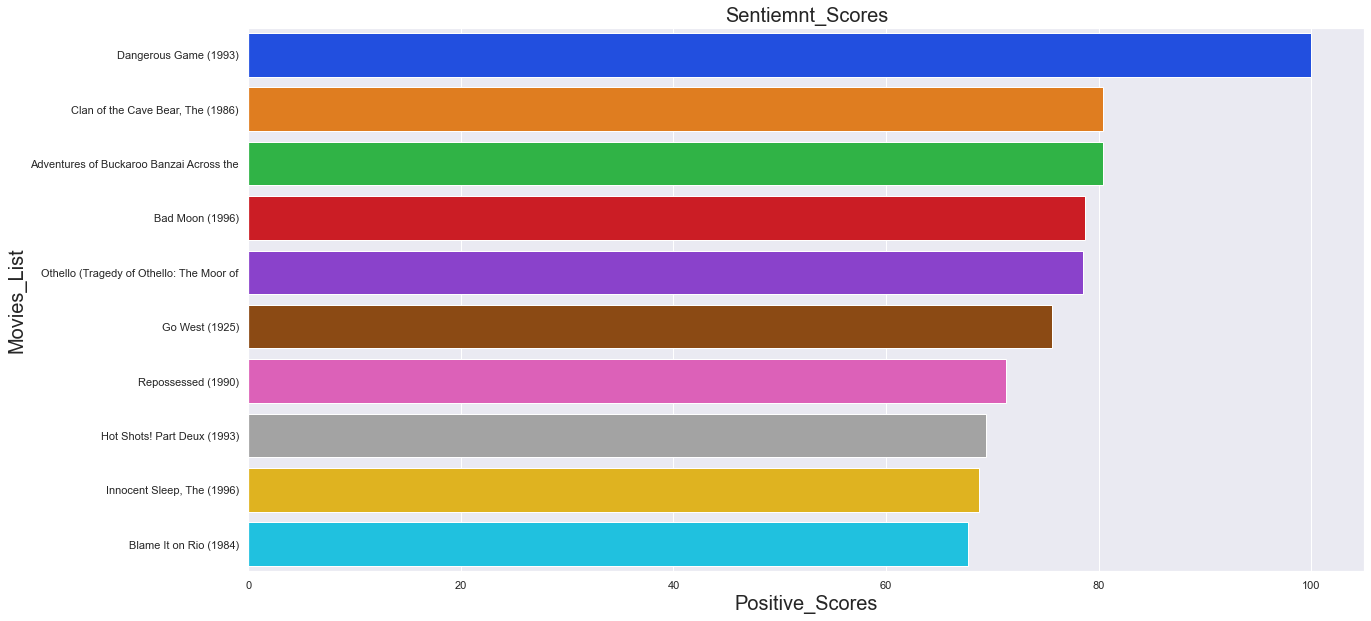

In [25]:
# Graphical view
plot = sns.barplot(x="Positive_Score", y="Title", data=df_positive_sent, palette="bright")
plot.set(xlabel='Positive_Scores', ylabel='Movies_List')
plot.set_title('Sentiemnt_Scores')
plt.show()

# 8. The bottom-10 videos that have the highest negative sentiment scores, which you calculated from the comments

In [26]:
# Statistical View
df_negative_sent = comments_df.nlargest(10, 'Negative_Score')
df_negative_sent['Title'] = df_negative_sent['Title'].str[:40]
df_negative_sent.drop(['Unnamed: 0'], axis=1)

,videoID,Title,Comments,Positive_Score,Negative_Score,Neutral_Score,Sentiments_Category
575,vs5F7bYgglQ,"Wife, The (1995)",['Boring'],0.0,100.0,0.0,Negative
2680,QRaWJy3NmFg,"Broken Hearts Club, The (2000)",['Sad Movie'],0.0,75.6,24.4,Negative
1379,mxbJdJV5bVY,"Governess, The (1998)","['Henery', 'Nah']",0.0,58.3,41.7,Negative
2120,6U7D7_LPoCk,"Natural, The (1984)",['Theme from Missing'],0.0,52.4,47.6,Negative
2593,EZ6lPjAN5Dw,Melody Time (1948),['Unboxing Transformers Revenge Of The Fallen ...,0.0,51.6,48.4,Negative
1535,wGpTIi2OxNY,Stardust Memories (1980),"[""I'm really sorry, but I absolutely hate Wood...",0.0,49.2,50.8,Negative
1111,xFCtD18fFng,Deceiver (1997),"['Hidden gem', 'Bad Assed Flick']",0.0,46.7,53.3,Negative
1726,noW6c70Yrbs,"Haunting, The (1963)","['Good horror movie', 'Why are there only thre...",21.6,46.5,31.9,Negative
1161,vK9g1ZOae1A,"Leading Man, The (1996)",['Why so many dislikes youtubers??'],0.0,45.5,54.5,Negative
958,_NEjdtWbstc,Falling in Love Again (1980),['UGH! I want to see it!!'],13.4,45.4,41.2,Negative


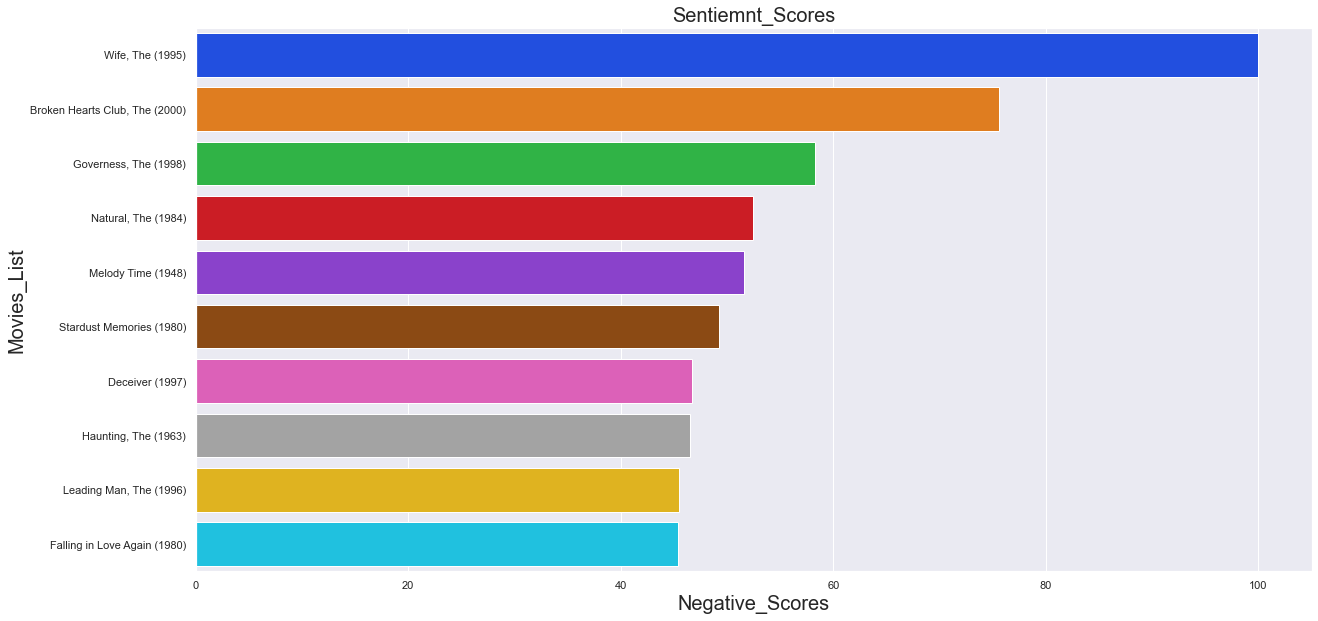

In [27]:
# Graphical view
plot = sns.barplot(x="Negative_Score", y="Title", data=df_negative_sent, palette="bright")
plot.set(xlabel='Negative_Scores', ylabel='Movies_List')
plot.set_title('Sentiemnt_Scores')
plt.show()